# 🎓 ReAct e Tool Calling com LangGraph
Disciplina: GENERATIVE AI & ADAVANCED NETS  
Curso: Tecnólogo em Inteligência Artificial

## 📌 Objetivos de Aprendizagem
Ao final desta sessão prática, você será capaz de:
- entender a diferença entre uma chamada simples de LLM e um fluxo baseado em Tool Calling;
- definir ferramentas que podem ser acionadas pelo LLM de forma estruturada;
- construir um agente ReAct com estado compartilhado, `ToolNode` e routing condicional no LangGraph;
- observar o ciclo de raciocínio, ação, observação e nova decisão em um caso de fraude;
- explicar por que ferramentas externas tornam um agente mais útil e controlável.

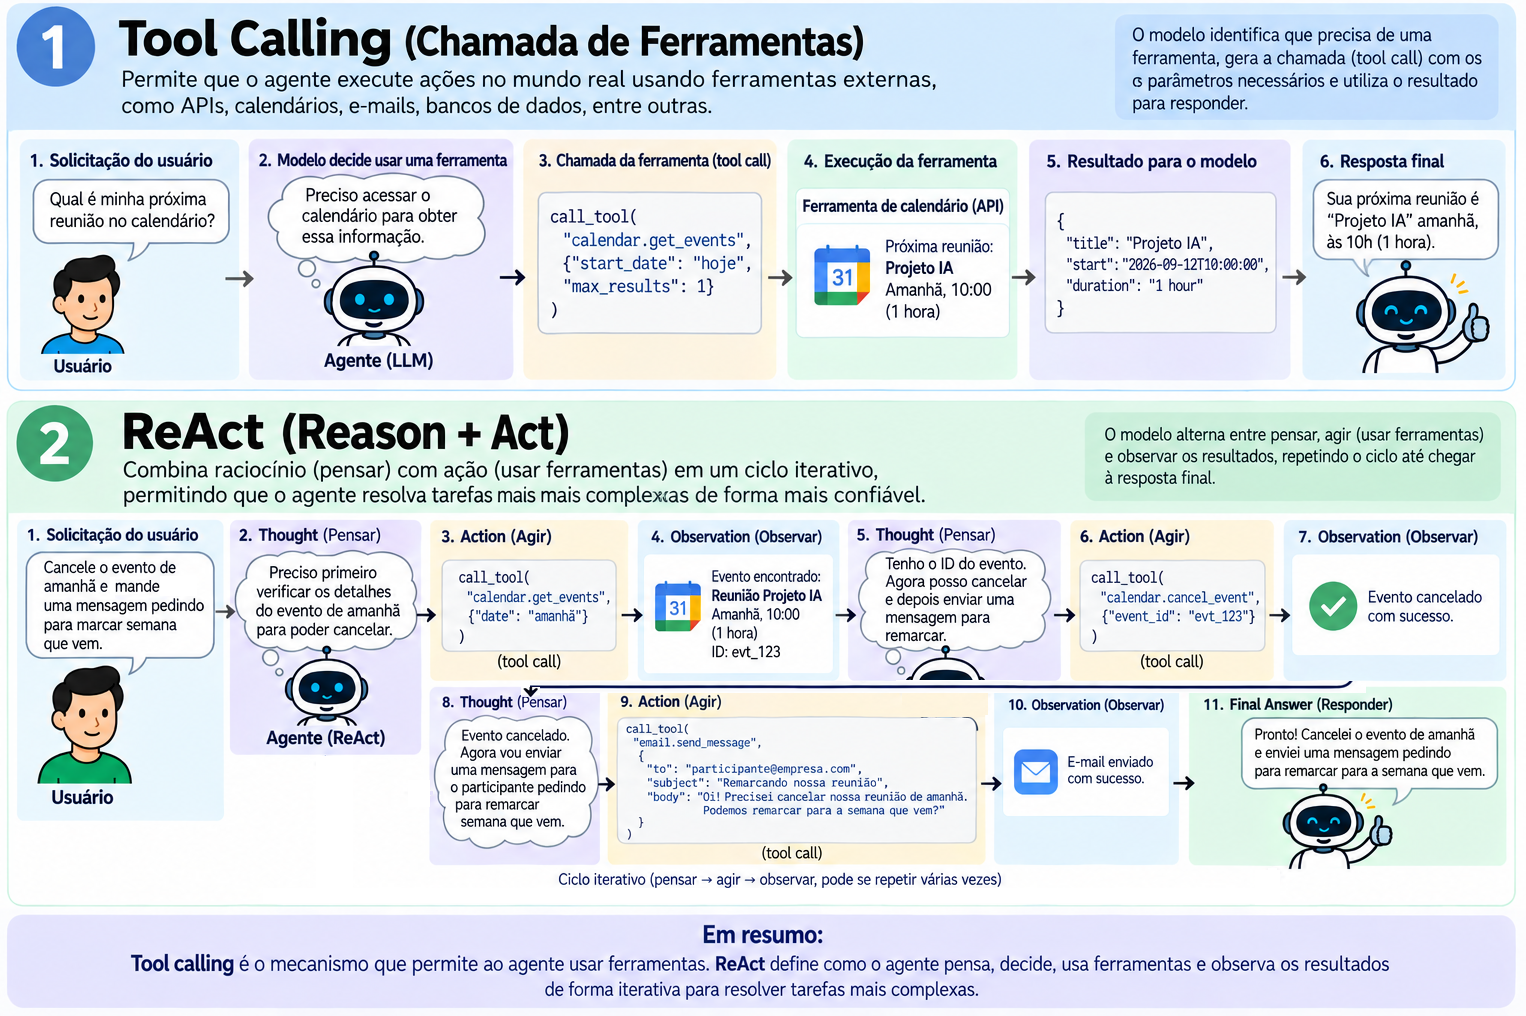

## 1. Introdução — o LLM sabe responder, mas sabe quando precisa consultar dados?

Na aula anterior, transformamos o **Agentic Fraud Rule Factory** em um sistema multiagente com SCOUT, LEGISLATOR, FRAUDADOR e AUDITOR.

Nesta aula, vamos voltar um passo para entender um mecanismo que permite aos agentes **agir sobre o mundo externo**: **Tool Calling**.

O problema é simples:

> O modelo conhece linguagem e padrões, mas não deve inventar informações que estão no nosso dataset.

Queremos que o LLM consiga perceber:

1. quando precisa consultar dados;
2. qual ferramenta deve usar;
3. quais argumentos deve enviar;
4. observar o resultado da ferramenta;
5. decidir se precisa de outra ação ou se já pode responder.

Esse ciclo é a base do padrão **ReAct — Reasoning + Acting**.

Nesta aula, vamos aplicar o conceito ao mesmo problema de fraude usado anteriormente. Não vamos criar novos agentes da fábrica de regras. O foco será exclusivamente em **ReAct, Tool Calling e LangGraph**.

## 2. Configuração do ambiente

Instalaremos apenas as bibliotecas necessárias para esta aula.

In [ ]:
%pip -q install -U langgraph langchain-core langchain-google-genai kagglehub pydantic

In [ ]:
import json
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Ambiente configurado.")

## 3. Configuração do LLM

Nesta aula vamos usar o Gemini 2.5 Flash. A API key deve estar no **Google Colab Secrets** com o nome `GOOGLE_API_KEY`.

Também configuramos um limitador de requisições para tornar a execução da aula mais previsível e evitar rajadas de chamadas ao modelo.

In [ ]:
from google.colab import userdata

try:
    GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")
except Exception:
    GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

if not GOOGLE_API_KEY:
    raise ValueError(
        "GOOGLE_API_KEY não encontrada. No Colab, abra Secrets e crie uma chave "
        "com o nome GOOGLE_API_KEY."
    )

print("GOOGLE_API_KEY carregada com sucesso.")

In [ ]:
from langchain_core.rate_limiters import InMemoryRateLimiter
from langchain_google_genai import ChatGoogleGenerativeAI

rate_limiter = InMemoryRateLimiter(
    requests_per_second=0.2,
    check_every_n_seconds=0.1,
    max_bucket_size=1,
)

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0.2,
    google_api_key=GOOGLE_API_KEY,
    rate_limiter=rate_limiter,
)

print("LLM pronto: Gemini 2.5 Flash")

## 4. Dados — continuamos usando o `Fraud_Data.csv`

O arquivo utilizado é o mesmo da aula anterior: **Fraud E-commerce**.

Fonte: `vbinh002/fraud-ecommerce`  
Arquivo: `Fraud_Data.csv`

Os dados são reais; nesta aula trabalharemos com uma amostra para manter a execução adequada ao Google Colab.

In [ ]:
import kagglehub

DATA_DIR = Path(kagglehub.dataset_download("vbinh002/fraud-ecommerce"))
DATA_PATH = DATA_DIR / "Fraud_Data.csv"

if not DATA_PATH.exists():
    candidates = list(DATA_DIR.rglob("Fraud_Data.csv"))
    if not candidates:
        raise FileNotFoundError(f"Fraud_Data.csv não encontrado em {DATA_DIR}")
    DATA_PATH = candidates[0]

print(f"Arquivo: {DATA_PATH}")

In [ ]:
EXPECTED_COLUMNS = [
    "user_id", "signup_time", "purchase_time", "purchase_value",
    "device_id", "source", "browser", "sex", "age", "ip_address", "class"
]

raw_df = pd.read_csv(DATA_PATH)
missing_columns = [col for col in EXPECTED_COLUMNS if col not in raw_df.columns]
if missing_columns:
    raise ValueError(f"Colunas esperadas ausentes: {missing_columns}")

df = raw_df[EXPECTED_COLUMNS].copy()
df["signup_time"] = pd.to_datetime(df["signup_time"], errors="coerce")
df["purchase_time"] = pd.to_datetime(df["purchase_time"], errors="coerce")
df["class"] = pd.to_numeric(df["class"], errors="coerce").fillna(0).astype(int)

df["account_age_hours"] = (
    (df["purchase_time"] - df["signup_time"]).dt.total_seconds() / 3600
).clip(lower=0)
df["purchase_hour"] = df["purchase_time"].dt.hour

df["device_frequency"] = df.groupby("device_id")["device_id"].transform("size")
df["ip_frequency"] = df.groupby("ip_address")["ip_address"].transform("size")

SAMPLE_SIZE = 50_000
work_df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=SEED).reset_index(drop=True)
train_df = work_df.sample(frac=0.8, random_state=SEED).copy()
test_df = work_df.drop(train_df.index).copy()

print(f"Dataset total: {len(df):,} linhas")
print(f"Amostra usada na aula: {len(work_df):,} linhas")
print(f"Treino para as ferramentas: {len(train_df):,} linhas")
print(f"Teste reservado: {len(test_df):,} linhas")

### Exploração rápida

As ferramentas que criaremos não inventarão informações. Elas consultarão diretamente o `train_df` e retornarão resultados calculados em Python.

In [ ]:
summary = pd.DataFrame({
    "Métrica": ["Casos", "Fraudes", "Taxa de fraude", "Compra média"],
    "Valor": [
        len(train_df),
        int(train_df["class"].sum()),
        train_df["class"].mean(),
        train_df["purchase_value"].mean(),
    ],
})

display(summary.style.format({"Valor": lambda x: f"{x:,.3f}" if isinstance(x, float) else f"{x:,}"}))

## 5. Antes do ReAct: o LLM consegue chamar uma ferramenta?

Antes de construir um agente, vamos observar o mecanismo mais básico de **Tool Calling**.

A ideia é:

```text
Usuário → LLM → decisão de ferramenta → argumentos estruturados
```

Ainda não existe loop. O modelo apenas decide se uma ferramenta deve ser chamada.

In [ ]:
from pydantic import BaseModel, Field
from langchain_core.tools import tool

# TODO crie uma classe SimilarCasesInput que herda de BaseModel.
class ...:

    # TODO defina "purchase_value" como float usando:
    # purchase_value: float = Field(description="Valor da compra")
    ...

    # TODO defina "age" como int usando:
    # age: int = Field(description="Idade do usuário")
    ...

    # TODO defina "source" como str usando:
    # source: str = Field(description="Origem da transação")
    ...

    # TODO defina "browser" como str usando:
    # browser: str = Field(description="Navegador utilizado")
    ...

    # TODO defina "limit" como int usando Field com:
    # default=5, ge=1, le=10 e description="Número máximo de casos".
    # Isso faz com que o valor padrão seja 5 e restringe o campo ao intervalo de 1 a 10.
    ...

In [ ]:
# TODO use @tool("find_similar_cases", args_schema=SimilarCasesInput)
# para registrar find_similar_cases como uma ferramenta que o agente poderá utilizar.
...
def find_similar_cases(
    purchase_value: float,
    age: int,
    source: str,
    browser: str,
    limit: int = 5,
):
    """Busca no conjunto de treino transações semelhantes ao caso informado."""
    candidates = train_df[
        (train_df["source"].astype(str).str.lower() == str(source).lower())
        & (train_df["browser"].astype(str).str.lower() == str(browser).lower())
    ].copy()

    if candidates.empty:
        candidates = train_df.copy()

    candidates["distance"] = (
        (candidates["purchase_value"] - purchase_value).abs()
        + 2.0 * (candidates["age"] - age).abs()
    )

    result = candidates.nsmallest(limit, "distance")[[
        "purchase_value", "age", "source", "browser", "class", "device_frequency", "ip_frequency"
    ]].copy()

    return result.to_dict(orient="records")

In [ ]:
# TODO use @tool("get_fraud_statistics")
# para registrar get_fraud_statistics como uma ferramenta que o agente poderá utilizar.
...
def get_fraud_statistics():
    """Retorna estatísticas calculadas do conjunto de treino."""
    by_source = (
        train_df.groupby("source")["class"]
        .agg(total="count", fraud_rate="mean")
        .sort_values("fraud_rate", ascending=False)
        .head(5)
        .round(4)
        .reset_index()
        .to_dict(orient="records")
    )

    by_browser = (
        train_df.groupby("browser")["class"]
        .agg(total="count", fraud_rate="mean")
        .sort_values("fraud_rate", ascending=False)
        .head(5)
        .round(4)
        .reset_index()
        .to_dict(orient="records")
    )

    return {
        "overall_fraud_rate": round(float(train_df["class"].mean()), 4),
        "top_sources_by_fraud_rate": by_source,
        "top_browsers_by_fraud_rate": by_browser,
    }

In [ ]:
tools = [find_similar_cases, get_fraud_statistics]
print("Ferramentas registradas:", [tool_.name for tool_ in tools])

In [ ]:
# TODO associe as ferramentas definidas em "tools" ao LLM usando bind_tools().
# Isso permite que o modelo possa solicitar a execução dessas ferramentas
# durante a conversa.
model_with_tools = ...

In [ ]:
prompt = """
Você é um analista de fraude. Analise o pedido do usuário e, quando precisar de dados do dataset,
use as ferramentas disponíveis. Não invente estatísticas.
Responda sempre em português do Brasil.

Caso: purchase_value=120, age=31, source=SEO, browser=Chrome.
Pergunta: existem sinais relevantes nesse caso?
"""

In [ ]:
# TODO invoque o modelo com ferramentas usando model_with_tools.invoke(prompt)
# e armazene a resposta retornada na variável response.
response = ...

In [ ]:
response.pretty_print()

In [ ]:
# TODO percorra todas as chamadas de ferramentas solicitadas pelo modelo
# armazenadas em response.tool_calls.
# TODO imprima cada chamada para visualizar qual ferramenta o modelo escolheu
# e quais argumentos ele enviou.
...

In [ ]:
# TODO execute a ferramenta solicitada pelo modelo.
# TODO use call["args"] para passar os argumentos retornados pelo LLM
# como argumentos nomeados para a função find_similar_cases e use .inovke
...

### O que acabamos de observar?

O modelo não executou a ferramenta sozinho. Ele **propôs uma chamada estruturada**.

Essa separação é importante:

```text
LLM
 ↓
decide a ação
 ↓
Tool Call estruturado
 ↓
[um executor do nosso sistema precisa executar]
```

Agora precisamos conectar essa decisão a um fluxo executável.

## 6. O ciclo ReAct

Agora vamos construir o loop:

```text
Pergunta
   ↓
LLM
   ↓
Tool Call?
  /    \
SIM     NÃO
 ↓       ↓
Tool    Resposta
 ↓
Observação
 ↓
LLM
 ↓
...
```

O LangGraph será responsável por controlar esse ciclo.

In [ ]:
from typing import Annotated, Sequence, TypedDict

from langchain_core.messages import BaseMessage, SystemMessage
from langgraph.graph.message import add_messages

| Recurso         | O que faz                                                                                                        | Exemplo                                        |
| --------------- | ---------------------------------------------------------------------------------------------------------------- | ---------------------------------------------- |
| `TypedDict`     | Define **a estrutura de um dicionário**                                                                          | `{"messages": ..., "number_of_steps": ...}`    |
| `Sequence`      | Indica que um campo contém uma **sequência de elementos**                                                        | `Sequence[BaseMessage]`                        |
| `Annotated`     | Permite adicionar **informações extras** a uma anotação de tipo                                                  | `Annotated[..., add_messages]`                 |
| `BaseMessage`   | Classe base usada pelo LangChain para representar **mensagens trocadas com o modelo**                            | `BaseMessage(...)`                             |
| `SystemMessage` | Representa uma **mensagem de sistema**, usada para fornecer instruções e contexto ao modelo                      | `SystemMessage(content="Você é um agente...")` |
| `add_messages`  | Função do LangGraph que **adiciona novas mensagens ao histórico existente**, em vez de simplesmente substituí-lo | `Annotated[..., add_messages]`                 |


In [ ]:
# TODO crie uma classe AgentState que herda TypedDict.
# O estado será utilizado para armazenar as informações compartilhadas
# entre os diferentes nós do agente.
class ...:

    # TODO defina "messages" como uma sequência de BaseMessage.
    # Use Annotated[Sequence[BaseMessage], add_messages] para indicar
    # que as novas mensagens devem ser adicionadas ao histórico existente
    # usando a função add_messages.
    ...

    # TODO defina "number_of_steps" como um inteiro para armazenar
    # o número de etapas já executadas pelo agente.
    ...

### Estado compartilhado

O histórico de mensagens é a memória de curto prazo do loop: ele preserva a pergunta, as chamadas de ferramenta e as observações retornadas pelas ferramentas.

In [ ]:
from langgraph.prebuilt import ToolNode

In [ ]:
SYSTEM_PROMPT = SystemMessage(content="""
Você é um agente de investigação antifraude.

Regras:
- Responda sempre em português do Brasil.
- Use as ferramentas quando precisar de dados do dataset.
- Não invente resultados nem estatísticas.
- Quando uma ferramenta retornar dados, use esses dados para orientar a próxima decisão.
- Não revele raciocínio interno detalhado; apresente apenas conclusões e evidências úteis.
""")


In [ ]:
# TODO crie a função call_model() que recebe o estado atual AgentState.
def call_model(state: AgentState):

    # TODO combine o SYSTEM_PROMPT com as mensagens armazenadas no estado.
    # Use list(state["messages"]) para transformar a sequência de mensagens em uma lista.
    messages = ...

    # TODO invoque o modelo com ferramentas usando model_with_tools.invoke(messages)
    # e armazene a resposta em response.
    response = ...

    # TODO retorne um dicionário atualizando o estado:
    # - adicione a nova resposta à lista "messages";
    # - incremente "number_of_steps" em 1.
    # TODO use state.get("number_of_steps", 0) para considerar 0
    # caso o contador ainda não exista no estado.
    return {
        "messages": ...,
        "number_of_steps": ...
    }

In [ ]:
# TODO crie um ToolNode usando a lista de ferramentas "tools".
# O ToolNode é responsável por executar automaticamente as ferramentas
# solicitadas pelo modelo.
tool_node = ...

In [ ]:
# TODO crie a função call_tools() para executar as ferramentas
# utilizando o estado atual do agente.
def call_tools(state: AgentState):

    # TODO execute o ToolNode passando o estado atual.
    # Escreva: result = tool_node.invoke(state)
    result = ...

    # TODO retorne o resultado da execução das ferramentas.
    return ...

In [ ]:
# TODO crie a função should_continue() para decidir se o workflow
# deve executar ferramentas ou finalizar a execução.
def should_continue(state: AgentState):

    # TODO obtenha a última mensagem armazenada no estado.
    # Escreva: last_message = state["messages"][-1]
    last_message = ...

    # TODO verifique se a última mensagem contém chamadas de ferramentas.
    # Use getattr(last_message, "tool_calls", None).
    # Se existirem chamadas, retorne "tools".
    if ...:
        return ...

    # TODO caso não existam chamadas de ferramentas, retorne "end".
    return ...

In [ ]:
print("Nós e routing definidos.")

### Construindo o grafo

Temos apenas dois tipos de nó:

- `llm`: decide o próximo passo;
- `tools`: executa as ferramentas solicitadas.

A aresta condicional decide se o fluxo volta para o LLM ou termina.

In [ ]:
from langgraph.graph import END, StateGraph

In [ ]:
# TODO crie um StateGraph usando AgentState como estrutura de estado compartilhado.
workflow = ...

# TODO adicione o nó "llm" associado à função call_model.
...

# TODO adicione o nó "tools" associado à função call_tools.
...

# TODO defina "llm" como ponto de entrada do workflow.
...

# TODO adicione arestas condicionais após o nó "llm" usando should_continue().
# Se should_continue() retornar "tools", o fluxo deve seguir para "tools".
# Se retornar "end", o fluxo deve seguir para END.
...

# TODO conecte o nó "tools" novamente ao nó "llm",
# permitindo que o modelo analise o resultado da ferramenta e continue o processo.
...

# TODO compile o workflow para criar o grafo executável e armazene em graph.
graph = ...

## 7. Visualizando o ReAct no LangGraph

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))

## 8. Demonstração — um agente investigando um caso

Agora veremos o comportamento completo.

O ponto mais importante não é apenas a resposta final. Observe os passos intermediários:

`LLM → TOOL → OBSERVAÇÃO → LLM → ...`

In [ ]:
case_row = train_df.iloc[0]

case_description = f"""
Investigue a seguinte transação:
- purchase_value: {case_row['purchase_value']}
- age: {int(case_row['age'])}
- source: {case_row['source']}
- browser: {case_row['browser']}
- device_frequency: {int(case_row['device_frequency'])}
- ip_frequency: {int(case_row['ip_frequency'])}

Use as ferramentas disponíveis para buscar evidências no dataset e explique os principais sinais encontrados.
No final, dê uma conclusão objetiva sobre o risco da transação.
"""
case_description

In [ ]:
# TODO crie o estado inicial do agente contendo:
# - uma mensagem do usuário com case_description;
# - number_of_steps iniciado em 0.
inputs = {
    ...
}

# TODO execute o grafo passando inputs e utilizando stream_mode="values"
# para receber o estado atualizado a cada etapa da execução.
for state in ...:

    # TODO obtenha a última mensagem presente no estado.
    last_message = ...

    print("\n" + "=" * 80)
    print(f"🧠 [REACT] etapa {state.get('number_of_steps', 0)} — {type(last_message).__name__}")

    last_message.pretty_print()

## 9. Experimento prático — modificar o comportamento de uma ferramenta

Agora a ideia é fazer uma pequena alteração e observar uma mudança real.

Vamos limitar a busca por casos semelhantes a transações do **mesmo source**, mas sem exigir o mesmo navegador.

Isso muda o contexto que chega ao LLM e permite discutir uma decisão de engenharia:

> **Quais critérios devem fazer parte de uma ferramenta?**

Em uma aplicação real, a ferramenta é parte do contrato entre o agente e o sistema externo.

In [ ]:
second_question = """
Quero investigar um caso de e-commerce com purchase_value=250, age=23, source=Ads e browser=Safari.
Primeiro encontre casos semelhantes. Depois consulte as estatísticas gerais de fraude.
Por fim, resuma quais evidências merecem atenção.
Responda em português do Brasil.
"""

In [ ]:
@tool("find_similar_cases_v2", args_schema=SimilarCasesInput)
def find_similar_cases_v2(
    purchase_value: float,
    age: int,
    source: str,
    browser: str,
    limit: int = 5,
):
    """Busca casos próximos pelo valor e idade, priorizando o mesmo source."""
    candidates = train_df[
        train_df["source"].astype(str).str.lower() == str(source).lower()
    ].copy()

    if candidates.empty:
        candidates = train_df.copy()

    candidates["distance"] = (
        (candidates["purchase_value"] - purchase_value).abs()
        + 2.0 * (candidates["age"] - age).abs()
        + 10.0 * (candidates["browser"].astype(str).str.lower() != str(browser).lower())
    )

    result = candidates.nsmallest(limit, "distance")[[
        "purchase_value", "age", "source", "browser", "class", "device_frequency", "ip_frequency"
    ]].copy()

    return result.to_dict(orient="records")

print("Ferramenta alternativa criada. O restante do grafo permanece igual.")

Para testar a alteração, substituímos apenas o conjunto de ferramentas ligado ao modelo. Isso mostra uma propriedade importante de arquiteturas agentivas: **a estratégia do agente pode permanecer igual enquanto suas capacidades externas mudam**.

In [ ]:
updated_tools = [find_similar_cases_v2, get_fraud_statistics]
updated_model_with_tools = llm.bind_tools(updated_tools)
updated_tool_node = ToolNode(updated_tools)


def updated_call_model(state: AgentState):
    messages = [SYSTEM_PROMPT] + list(state["messages"])
    response = updated_model_with_tools.invoke(messages)
    return {
        "messages": [response],
        "number_of_steps": state.get("number_of_steps", 0) + 1,
    }


def updated_call_tools(state: AgentState):
    return updated_tool_node.invoke(state)

updated_workflow = StateGraph(AgentState)
updated_workflow.add_node("llm", updated_call_model)
updated_workflow.add_node("tools", updated_call_tools)
updated_workflow.set_entry_point("llm")
updated_workflow.add_conditional_edges(
    "llm",
    should_continue,
    {"tools": "tools", "end": END},
)
updated_workflow.add_edge("tools", "llm")
updated_graph = updated_workflow.compile()

print("Grafo atualizado compilado.")

In [ ]:
updated_inputs = {
    "messages": [("user", second_question)],
    "number_of_steps": 0,
}

for state in updated_graph.stream(updated_inputs, stream_mode="values"):
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        print("\n🔧 [TOOL CALL]")
        for call in last_message.tool_calls:
            print(f"Ferramenta: {call['name']}")
            print(f"Argumentos: {call['args']}")
    elif type(last_message).__name__ == "ToolMessage":
        print("\n🔧 [TOOL RESULT]")
        print(last_message.content)
    else:
        print("\n🧠 [LLM]")
        last_message.pretty_print()

## 10. Interpretação — o que o ReAct resolveu?

Sem Tool Calling, o LLM poderia tentar responder usando apenas o que conhece ou receber todos os dados antecipadamente.

Com Tool Calling + LangGraph, temos um fluxo no qual:

```text
LLM
 ↓
decide qual ação precisa
 ↓
tool call estruturado
 ↓
Python executa a ferramenta
 ↓
resultado volta ao estado
 ↓
LLM decide novamente
```

O comportamento deixou de ser uma única resposta e passou a ser um **loop controlado de decisão e ação**.

### ReAct não significa apenas “usar ferramentas”

A parte importante é o ciclo:

**decidir → agir → observar → decidir novamente**.

O LangGraph fornece a estrutura para controlar esse ciclo de forma explícita, enquanto o Tool Calling fornece uma interface estruturada entre o LLM e as ferramentas.

# 🎯 Conclusão
Nesta aula prática, vimos como:
- usar **Tool Calling** para permitir que o LLM solicite ações de forma estruturada;
- criar ferramentas Python para consultar dados reais de fraude;
- usar **LangGraph** para implementar o ciclo ReAct de decisão, ação e observação;
- usar estado compartilhado e routing condicional para controlar o fluxo do agente;
- observar como a alteração de uma ferramenta pode mudar o comportamento do agente sem reescrever sua lógica central.